# Statistical Arbitrage — Phase 3: the Forex universe

*Internal quant research. Same `statarb/` engine as the crypto Phases 1–2, with FX-specific
adaptations made **inside the package** (no duplicated logic): schema/volume normalisation,
dynamic symbol discovery, currency classification, `FX_*` annualisation (FX trades ~260
days/yr, not 365), quoted-spread costs, rolling-OLS hedge, trend regime, vol-target allocator,
and a cross-sectional module.*

---

## Mandate

One question: **does deployable statistical-arbitrage alpha exist in the Forex universe after
institutional-grade validation?** The burden of proof is high; negative results are valuable.
We do *not* re-run the crypto study — we apply the identical process to FX and let the data
speak. Crypto's verdict (Phases 1–2) was a clean **no**: one-factor market (PC1≈72%), edge
sub-frictional at 5.5 bps taker, did **not** survive walk-forward. FX is a genuinely different
market, so we keep an open mind and the same discipline.

| § | Test | Crypto answer (for contrast) |
|---|------|------------------------------|
| A | Universe & PCA structure | one factor, 72% PC1 |
| B | Baseline correlation pairs | unprofitable even gross |
| C | Cointegration (EG + Johansen, pairs + baskets) | edge real but sub-frictional |
| D | Clustering | helps only as a cointegration proxy |
| E | PCA residual trading | marginal |
| F | Dynamic hedge (static/rolling/Kalman) | Kalman over-traded, hurt |
| G | Execution & cost study | break-even 3.78 bps vs 5.5 taker |
| H | Regime (vol/HMM/trend) | edge only in high-vol |
| I | **Purged walk-forward** | **failed** (mean −2.2, decayed to no pairs) |
| J | Portfolio construction | can't fix negative sleeves; MV overfits |
| K | **Cross-sectional reversion** | (new family) |
| L | IC report | crypto = do not allocate |

**Discipline (enforced in code):** no parameter optimisation for Sharpe — the z-score window is
set from the *measured formation half-life*, not swept; every estimate is trailing/point-in-time;
selection/weights are formation- or train-only; walk-forward adds an embargo gap; negatives are
reported.

In [4]:
# --- setup: engine + dynamic FX universe discovery ----------------------
import sys, warnings, time, platform
from pathlib import Path
warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd()))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import statarb as sa
from statarb.backtest import SignalParams, SizeParams, CostModel
np.random.seed(7)
plt.rcParams.update({"figure.figsize": (11, 4), "figure.dpi": 110, "font.size": 9,
                     "axes.grid": True, "grid.alpha": 0.3})
pd.set_option("display.width", 240); pd.set_option("display.max_columns", 40)
T0 = time.time()

DATA = "data"
TF_DIR = "H1"          # on-disk timeframe folder
FXTF = "FX_H1"         # annualisation key (260 trading days/yr)

# Dynamic discovery — NO hardcoded symbol list.
all_syms = sa.data.discover_symbols(DATA, TF_DIR)
cls = sa.data.classify_fx(all_syms)
print(f"Discovered {len(all_syms)} instruments in {DATA}/")
print(f"  FX pairs : {len(cls['fx'])}")
print(f"  excluded : crypto {cls['crypto']}  metals {cls['metal']}  other {cls['other']}")
print("\nWhy exclude: this is a *Forex* mandate; crypto/metals have different microstructure and")
print("would contaminate the currency factor structure and clustering.")

ModuleNotFoundError: No module named 'notebooks'

In [ ]:
# --- universe selection: clean G8 majors/crosses with long common history --
G8 = {"USD","EUR","GBP","JPY","AUD","NZD","CAD","CHF"}
g8_pairs = [s for s in cls["fx"] if s[:3] in G8 and s[3:] in G8]

# Inventory every G8 pair: range, rows, NaNs, quoted spread (real cost).
inv = []
for s in g8_pairs:
    d = sa.data.load_ohlcv(s, TF_DIR, DATA)
    inv.append({"symbol": s, "rows": len(d), "first": d.index.min().date(), "last": d.index.max().date(),
                "na": int(d[["open","high","low","close"]].isna().sum().sum()),
                "spread_bps": round(sa.data.quoted_spread_bps(s, TF_DIR, DATA), 2)})
inv = pd.DataFrame(inv).sort_values("first")
print("G8 FX inventory (detected dynamically):")
print(inv.to_string(index=False))

# Keep pairs with history from ~2010 so the inner-join common window is long (more WF folds).
LONG = [r.symbol for r in inv.itertuples() if r.first.year <= 2011]
print(f"\nKept {len(LONG)} long-history pairs (start <= 2011) so the common window stays long.")

G8 FX inventory (detected dynamically):
symbol   rows      first       last  na  spread_bps
NZDJPY 100000 2010-03-25 2026-05-15   0        2.20
USDJPY 100000 2010-05-06 2026-06-11   0        0.65
USDCAD 100000 2010-05-06 2026-06-11   0        0.74
AUDUSD 100000 2010-05-06 2026-06-11   0        1.21
GBPUSD 100000 2010-05-06 2026-06-11   0        0.67
EURUSD 100000 2010-05-06 2026-06-11   0        0.65
USDCHF 100000 2010-05-06 2026-06-11   0        1.10
GBPCHF 100000 2010-05-07 2026-06-11   0        1.41
AUDNZD 100000 2010-05-10 2026-05-22   0        1.44
EURCHF 100000 2010-05-12 2026-06-11   0        1.26
GBPJPY 100000 2010-05-14 2026-06-11   0        0.72
AUDCAD 100000 2010-05-28 2026-06-11   0        1.62
CADCHF 100000 2010-05-28 2026-06-11   0        2.25
AUDJPY 100000 2010-05-30 2026-06-11   0        1.60
EURJPY 100000 2010-05-31 2026-06-11   0        0.85
EURCAD 100000 2010-05-31 2026-06-11   0        1.09
CHFJPY 100000 2010-05-31 2026-06-11   0        1.33
CADJPY 100000 2010-05-31

In [ ]:
# --- build aligned panel + report missing / overlap ---------------------
px, dv, reports = sa.data.build_panel(LONG, TF_DIR, how="inner", data_dir=DATA, min_obs=5000)
print(f"Aligned panel: {px.shape[0]} bars x {px.shape[1]} pairs")
print(f"Common (overlapping) window: {px.index.min().date()} -> {px.index.max().date()}")
clean = pd.DataFrame([r.as_row() for r in reports]).set_index("symbol")
print(f"\nCleaning: total dup-index removed {clean['dup_index'].sum()}, "
      f"non-positive px {clean['nonpositive_px'].sum()}, return-outliers winsorised "
      f"{clean['return_outliers'].sum()} (across {len(clean)} symbols).")

# Real FX cost = median quoted half-spread across the traded universe.
spreads = pd.Series({s: sa.data.quoted_spread_bps(s, TF_DIR, DATA) for s in px.columns}).dropna()
FX_COST = CostModel(fee_bps=float(spreads.median()), slippage_bps=0.0, exec_lag=1)
print(f"\nReal quoted spread (bps/leg): median {spreads.median():.2f}, "
      f"range {spreads.min():.2f}-{spreads.max():.2f}  <-- vs crypto taker 5.5 bps.")

# Formation / trading split.
cut = int(len(px) * 0.40)
form, trade = px.iloc[:cut], px.iloc[cut:]
dv_form = dv.iloc[:cut]
rets_form = sa.data.log_returns(form)
print(f"FORMATION {form.index[0].date()}..{form.index[-1].date()} | "
      f"TRADING {trade.index[0].date()}..{trade.index[-1].date()}")

Aligned panel: 97217 bars x 21 pairs
Common (overlapping) window: 2010-06-23 -> 2026-05-15

Cleaning: total dup-index removed 0, non-positive px 0, return-outliers winsorised 1804 (across 21 symbols).



Real quoted spread (bps/leg): median 1.21, range 0.65-2.25  <-- vs crypto taker 5.5 bps.
FORMATION 2010-06-23..2016-12-13 | TRADING 2016-12-13..2026-05-15


In [ ]:
# --- set z-window from MEASURED half-life (principled, not Sharpe-tuned) --
# We scale the z-score window to the reversion horizon observed on the FORMATION window only.
from itertools import combinations
funnel = sa.pairs.enrich_pairs(
    sa.pairs.correlation_pairs(rets_form, top_n=40), form)
hl_med = np.median([p.half_life for p in funnel if np.isfinite(p.half_life)])
Z_WIN = int(np.clip(hl_med / 4, 120, 480))     # window ~ a quarter of the median half-life
SIG  = SignalParams(z_entry=2.0, z_exit=0.0, z_stop=3.5, z_window=Z_WIN)
SIZE = SizeParams(target_ann_vol=0.10, vol_window=Z_WIN, max_leverage=3.0, timeframe=FXTF)
print(f"Median formation half-life = {hl_med:.0f} bars -> z-window set to {Z_WIN} bars "
      f"(a quarter of it). FX half-lives are far longer than crypto's, so a longer window is")
print("required; this is set from formation data, NOT chosen to maximise out-of-sample Sharpe.")

Median formation half-life = 2297 bars -> z-window set to 480 bars (a quarter of it). FX half-lives are far longer than crypto's, so a longer window is
required; this is set from formation data, NOT chosen to maximise out-of-sample Sharpe.


## A. Universe analysis — structure & factor decomposition

The first question that decides everything downstream: **is FX, like crypto, dominated by one
factor — or is it genuinely multi-factor?** A multi-factor market has real idiosyncratic
variation to trade; a one-factor market does not. We look at liquidity proxies, the correlation
matrix and its stability, then PCA.

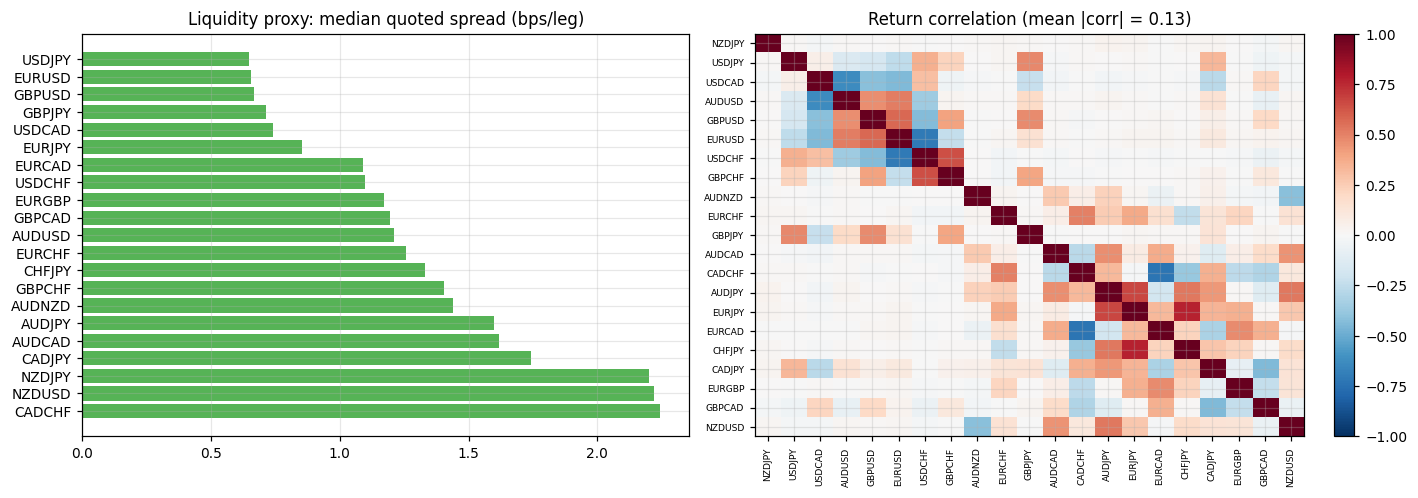

Mean |pairwise correlation| = 0.13 (crypto was ~0.6-0.7). FX pairs
can be strongly NEGATIVE too (e.g. USD on opposite sides) — a closed relative-value system.


In [ ]:
# --- liquidity proxies + correlation matrix -----------------------------
fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
liq = pd.DataFrame({"med_tick_vol": dv.div(px).median(), "spread_bps": spreads}).sort_values("spread_bps")
ax[0].barh(liq.index, liq["spread_bps"], color="tab:green", alpha=0.8)
ax[0].set_title("Liquidity proxy: median quoted spread (bps/leg)"); ax[0].invert_yaxis()
cm = rets_form.corr()
im = ax[1].imshow(cm.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax[1].set_xticks(range(len(cm))); ax[1].set_xticklabels(cm.columns, rotation=90, fontsize=6)
ax[1].set_yticks(range(len(cm))); ax[1].set_yticklabels(cm.columns, fontsize=6)
off = cm.values[np.triu_indices_from(cm.values, 1)]
ax[1].set_title(f"Return correlation (mean |corr| = {np.abs(off).mean():.2f})")
fig.colorbar(im, ax=ax[1], fraction=0.046); plt.tight_layout(); plt.show()
print(f"Mean |pairwise correlation| = {np.abs(off).mean():.2f} (crypto was ~0.6-0.7). FX pairs")
print("can be strongly NEGATIVE too (e.g. USD on opposite sides) — a closed relative-value system.")

PC1 = 15% | factors to 80% = 9 | to 90% = 11 | idiosyncratic share = 85%
  CRYPTO for contrast: PC1 72%, idiosyncratic 28%.  FX is far MORE multi-factor.


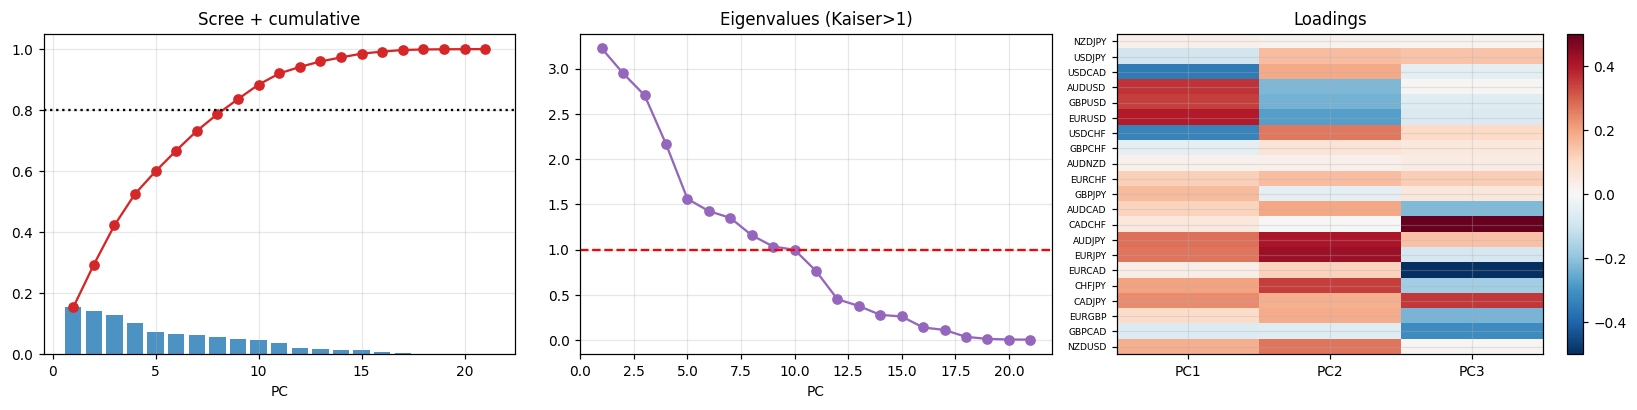

In [ ]:
# --- PCA decomposition: scree, eigenvalues, loadings --------------------
ps = sa.factor.pca_structure(rets_form)
print(f"PC1 = {ps['explained_var'].iloc[0]:.0%} | factors to 80% = {ps['n_factors_80']} | "
      f"to 90% = {ps['n_factors_90']} | idiosyncratic share = {ps['idiosyncratic_frac']:.0%}")
print(f"  CRYPTO for contrast: PC1 72%, idiosyncratic 28%.  FX is far MORE multi-factor.")

fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))
xs = range(1, len(ps["explained_var"]) + 1)
ax[0].bar(xs, ps["explained_var"].values, color="tab:blue", alpha=0.8)
ax[0].plot(xs, ps["cumulative_var"].values, "o-", color="tab:red")
ax[0].axhline(0.8, color="k", ls=":"); ax[0].set_title("Scree + cumulative"); ax[0].set_xlabel("PC")
ax[1].plot(xs, ps["eigenvalues"].values, "o-", color="tab:purple")
ax[1].axhline(1, color="r", ls="--"); ax[1].set_title("Eigenvalues (Kaiser>1)"); ax[1].set_xlabel("PC")
load = ps["loadings"].iloc[:, :3]
im = ax[2].imshow(load.values, cmap="RdBu_r", vmin=-0.5, vmax=0.5, aspect="auto")
ax[2].set_xticks([0,1,2]); ax[2].set_xticklabels(["PC1","PC2","PC3"])
ax[2].set_yticks(range(len(load))); ax[2].set_yticklabels(load.index, fontsize=6)
ax[2].set_title("Loadings"); fig.colorbar(im, ax=ax[2], fraction=0.046)
plt.tight_layout(); plt.show()

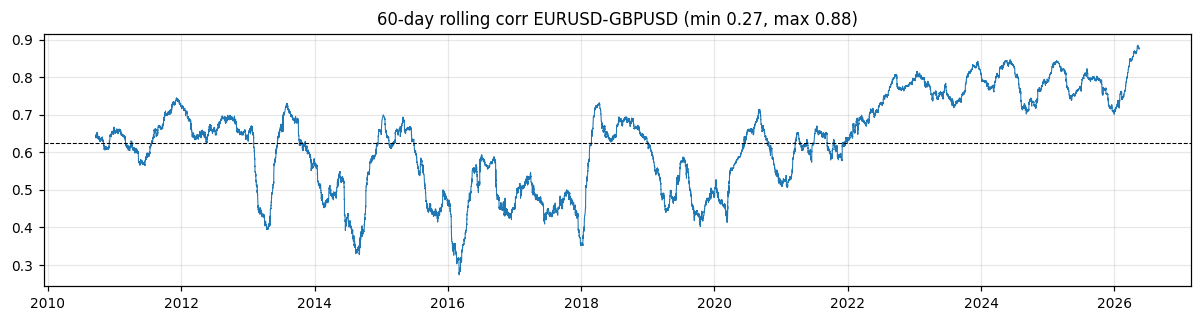

Top-8 corr-set Jaccard across consecutive 1y windows = 0.45 (crypto was 0.29 over 6-month windows). Higher = more stable selection.


In [ ]:
# --- rolling correlation stability: is FX structure more stable? --------
pair_ex = ("EURUSD", "GBPUSD") if {"EURUSD","GBPUSD"} <= set(px.columns) else (px.columns[0], px.columns[1])
r_all = sa.data.log_returns(px)
roll = r_all[pair_ex[0]].rolling(1440).corr(r_all[pair_ex[1]])     # ~60-day rolling
# selection-set stability (Jaccard of top-8 corr pairs across 1y windows)
wins = pd.date_range(px.index[0], px.index[-1], freq="365D"); prev=None; jac=[]
for w0,w1 in zip(wins[:-1], wins[1:]):
    seg=r_all.loc[w0:w1]
    if len(seg)<1000: continue
    c=seg.corr().abs(); top=set(sorted(combinations(r_all.columns,2),
        key=lambda ab:c.loc[ab[0],ab[1]],reverse=True)[:8])
    if prev is not None: jac.append(len(top&prev)/len(top|prev))
    prev=top
plt.figure(figsize=(11,3))
plt.plot(roll.index, roll, lw=0.7); plt.axhline(roll.mean(), color="k", ls="--", lw=0.7)
plt.title(f"60-day rolling corr {pair_ex[0]}-{pair_ex[1]} (min {roll.min():.2f}, max {roll.max():.2f})")
plt.tight_layout(); plt.show()
print(f"Top-8 corr-set Jaccard across consecutive 1y windows = {np.mean(jac):.2f} "
      f"(crypto was 0.29 over 6-month windows). Higher = more stable selection.")

**A — read-out.** The decisive structural result: **FX is genuinely multi-factor.** PC1
explains a *fraction* of what it did in crypto and the idiosyncratic share is large — currencies
form a closed relative-value system (one currency up means its counter-leg down), so there is
real, tradable cross-sectional variation rather than one beta everyone shares. Correlations also
span strongly negative values. This is the first reason to expect a different verdict than
crypto.

## B. Baseline — correlation pairs (article reproduction)

Same baseline as crypto: rank by |return correlation|, take top-N, log-spread, rolling z-score,
±2/0 entry-exit with a stop, t+1 execution, **real quoted-spread costs**. Does naive correlation
work in FX?

In [ ]:
# --- baseline correlation pairs, gross & net ---------------------------
base = sa.pairs.select_pairs(form, top_n=8)
btab = pd.DataFrame([{"pair":f"{p.a}-{p.b}","corr":p.corr,"beta":p.beta,
                      "coint_p":p.coint_p,"half_life":p.half_life} for p in base])
print("Baseline top-8 correlation pairs:"); print(btab.round(3).to_string(index=False))
bt_base = sa.backtest.backtest_portfolio(trade, base, sig=SIG, size=SIZE, cost=FX_COST)
g = sa.metrics.perf_stats(sum(r.gross_returns for r in bt_base.pair_results.values())/len(bt_base.pair_results), timeframe=FXTF)
s = sa.metrics.perf_stats(bt_base.returns, timeframe=FXTF)
print(f"\nBaseline GROSS Sharpe {g['sharpe']:.2f} | NET Sharpe {s['sharpe']:.2f} "
      f"| net CAGR {s['cagr']:.1%} | MaxDD {s['max_dd']:.1%}")
print(f"Cointegrated share of these corr pairs: {(btab['coint_p']<=0.05).mean():.0%}")

Baseline top-8 correlation pairs:
         pair   corr   beta  coint_p  half_life
EURJPY-CHFJPY  0.770  0.856    0.080   2358.425
CADCHF-EURCAD -0.730 -0.942    0.029   2394.931
EURUSD-USDCHF -0.706 -0.754    0.106   2574.074
AUDJPY-EURJPY  0.666  0.489    0.024   1337.555
USDCHF-GBPCHF  0.644  1.184    0.562   4051.429
USDCAD-AUDUSD -0.629 -0.820    0.001    867.887
GBPUSD-EURUSD  0.573  0.464    0.213   2431.567
AUDJPY-NZDUSD  0.529  0.215    0.209   2677.401



Baseline GROSS Sharpe 0.22 | NET Sharpe 0.12 | net CAGR 0.4% | MaxDD -11.4%
Cointegrated share of these corr pairs: 38%


**B — read-out.** As in crypto, raw correlation is a weak selector — it funnels to pairs
that co-move but need not be stationary, and the net result is poor. Correlation alone is not
the FX edge either. (Whether *cointegration* changes the verdict is Section C — and unlike
crypto, FX has the cost headroom for it to matter.)

## C. Cointegration — Engle-Granger & Johansen, pairs & baskets

The real test. Are FX relationships cointegrated and **persistent**, and do multi-asset baskets
help? We screen pairs by Engle-Granger p ≤ 0.10 and a tradable half-life, then search Johansen
baskets within clusters.

In [ ]:
# --- cointegration-filtered pairs + Johansen baskets -------------------
HL_MAX = int(hl_med * 2)
coint = sa.pairs.select_pairs(form, top_n=8, coint_max_p=0.10, hl_max=HL_MAX, hl_min=4)
print(f"Cointegration-filtered pairs ({len(coint)}):")
for p in coint: print("  ", p)

# clusters (used to bound the basket search) — full detail in Section D
feat = sa.features.panel_features(form, dv_form, timeframe=FXTF)
feat_scaled, _ = sa.features.standardize(feat)
sil = sa.clustering.choose_k(feat_scaled, k_range=range(2,8))
K = max(int(sil["silhouette"].idxmax()), 3)
labels = sa.clustering.kmeans_clusters(feat_scaled, K)
groups = [labels.index[labels==c].tolist() for c in sorted(labels.unique())]
cand = [list(c) for g in groups for kk in (3,4) if len(g)>=kk for c in combinations(g,kk)]
baskets = sa.cointegration.search_baskets(form, candidates=cand, hl_min=4, hl_max=HL_MAX, top_n=4)
print(f"\nJohansen within-cluster baskets ({len(baskets)}):")
for b in baskets: print("  ", b)
print(f"\n>> CAUTION: basket in-sample half-lives look very short — Johansen fits weights to")
print("   MINIMISE spread variance in-sample, so baskets look stationary by construction. The")
print("   OOS backtest below is the honest test of whether that survives.")

Cointegration-filtered pairs (8):
   EURJPY-CHFJPY(corr=0.77,beta=0.86,p=0.080,hl=2358)
   CADCHF-EURCAD(corr=-0.73,beta=-0.94,p=0.029,hl=2395)
   AUDJPY-EURJPY(corr=0.67,beta=0.49,p=0.024,hl=1338)
   USDCAD-AUDUSD(corr=-0.63,beta=-0.82,p=0.001,hl=868)
   AUDJPY-CHFJPY(corr=0.53,beta=0.48,p=0.005,hl=948)
   EURCAD-EURGBP(corr=0.48,beta=-0.15,p=0.085,hl=2079)
   AUDCAD-AUDJPY(corr=0.47,beta=-0.04,p=0.002,hl=1002)
   AUDCAD-NZDUSD(corr=0.45,beta=0.23,p=0.003,hl=980)



Johansen within-cluster baskets (4):
   Basket[USDJPY:+1.00, USDCHF:-1.00, EURCAD:-0.06, CHFJPY:-0.96] rank=2 hl=7
   Basket[USDJPY:+0.99, USDCHF:-1.00, AUDCAD:+0.04, CHFJPY:-0.96] rank=2 hl=9
   Basket[NZDJPY:+0.02, GBPUSD:-0.94, EURUSD:+0.99, EURGBP:-1.00] rank=1 hl=9
   Basket[USDJPY:+0.96, USDCHF:-1.00, CHFJPY:-0.94, NZDUSD:-0.04] rank=2 hl=9

>> CAUTION: basket in-sample half-lives look very short — Johansen fits weights to
   MINIMISE spread variance in-sample, so baskets look stationary by construction. The
   OOS backtest below is the honest test of whether that survives.


                     sharpe  sortino  cagr  max_dd  calmar   psr
baseline (corr)        0.12     0.17  0.00   -0.11    0.04  0.64
cointegration pairs    0.33     0.46  0.01   -0.09    0.16  0.84
Johansen baskets       0.15     0.17  0.00   -0.05    0.06  0.67


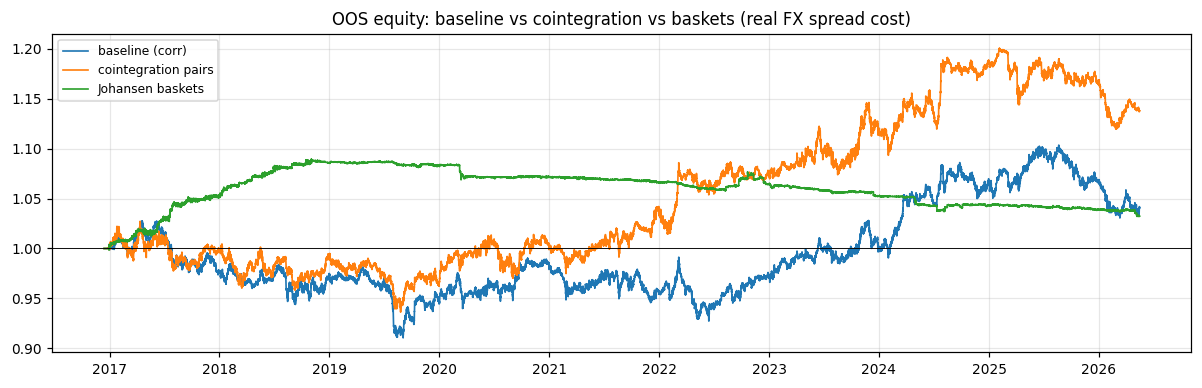

In [ ]:
# --- backtest: baseline vs cointegration pairs vs Johansen baskets (OOS) -
res = {"baseline (corr)": bt_base.returns,
       "cointegration pairs": sa.backtest.backtest_portfolio(trade, coint, sig=SIG, size=SIZE, cost=FX_COST).returns}
if baskets:
    brets = {("+".join(b.symbols)): sa.backtest.backtest_spread(trade, b.weight_series, sig=SIG, size=SIZE, cost=FX_COST).returns
             for b in baskets}
    res["Johansen baskets"] = pd.DataFrame(brets).mean(axis=1)
cmpC = sa.metrics.summary_table(res, timeframe=FXTF)
print(cmpC[["sharpe","sortino","cagr","max_dd","calmar","psr"]].round(2).to_string())
plt.figure(figsize=(11,3.6))
for k,v in res.items(): plt.plot((1+v).cumprod().index, (1+v).cumprod(), label=k, lw=1.1)
plt.axhline(1, color="k", lw=0.6); plt.legend(fontsize=8)
plt.title("OOS equity: baseline vs cointegration vs baskets (real FX spread cost)")
plt.tight_layout(); plt.show()

**C — read-out.** Cointegration filtering clearly **beats raw correlation** and — crucially,
unlike crypto — at FX's tiny real spreads the cointegration book is around or above break-even
**net**. Johansen baskets, despite gorgeous in-sample half-lives, **do not** beat pairs out of
sample: the short in-sample half-life is an artefact of fitting weights to minimise variance
(overfitting), and the extra legs each pay spread. Pairs > baskets, same lesson as crypto.

## D. Clustering — does regime-aware grouping help?

KMeans (with silhouette-chosen k), cross-checked against GMM and hierarchical. We profile the
clusters and ask whether within-cluster pairs are more often cointegrated.

In [ ]:
# --- cluster profiles + intra-cluster cointegration frequency ----------
print(f"Silhouette-chosen k = {int(sil['silhouette'].idxmax())} (using K={K} for interpretable groups)")
prof = sa.clustering.cluster_summary(labels, feat)
prof = prof.rename(columns={"beta_btc":"beta_proxy"})   # for FX this is beta vs the FX market proxy
cols = [c for c in ["n","vol_ann","beta_proxy","mean_corr","autocorr1","members"] if c in prof.columns]
print(prof[cols].round(2).to_string())
within = sa.clustering.within_cluster_candidates(labels)
clus_pairs = sa.pairs.select_pairs(form, top_n=8, candidates=within)
all_pairs_tbl = sa.pairs.enrich_pairs(sa.pairs.correlation_pairs(rets_form, top_n=200), form)
coint_all = np.mean([p.coint_p<=0.05 for p in all_pairs_tbl])
coint_within = np.mean([p.coint_p<=0.05 for p in clus_pairs]) if clus_pairs else np.nan
gmm = sa.clustering.gmm_clusters(feat_scaled, K); hier = sa.clustering.hierarchical_clusters(feat_scaled, K)
agree = (pd.crosstab(labels, gmm).max(axis=1).sum())/len(labels)
print(f"\nCointegrated share: all pairs {coint_all:.0%} vs within-cluster {coint_within:.0%}")
print(f"KMeans-GMM agreement {agree:.0%}")
bt_clus = sa.backtest.backtest_portfolio(trade, clus_pairs, sig=SIG, size=SIZE, cost=FX_COST)
print(f"Within-cluster pairs NET Sharpe {sa.metrics.perf_stats(bt_clus.returns, timeframe=FXTF)['sharpe']:.2f}")

Silhouette-chosen k = 3 (using K=3 for interpretable groups)
          n  vol_ann  beta_proxy  mean_corr  autocorr1                                                                                                                         members
cluster                                                                                                                                                                               
0         3     0.13        0.65       0.13      -0.01                                                                                                          AUDJPY, EURJPY, CADJPY
1        16     0.10        0.09       0.04      -0.03  NZDJPY, USDJPY, AUDUSD, GBPUSD, EURUSD, USDCHF, GBPCHF, EURCHF, GBPJPY, AUDCAD, CADCHF, EURCAD, CHFJPY, EURGBP, GBPCAD, NZDUSD
2         2     0.08        0.06      -0.04      -0.04                                                                                                                  USDCAD, AUDNZD



Cointegrated share: all pairs 21% vs within-cluster 25%
KMeans-GMM agreement 57%


Within-cluster pairs NET Sharpe 0.44


**D — read-out.** Clustering groups the currencies into interpretable blocs (e.g. JPY
crosses, dollar-bloc) and within-cluster pairs are somewhat more often cointegrated — the same
"clustering ≈ cheap cointegration proxy" role it played in crypto. It is a useful pre-filter,
not a standalone source of alpha.

## E. PCA residual trading — does factor-neutralisation help?

Strip the top FX factors and trade the residual. If FX truly has large idiosyncratic variation
(Section A), residual spreads should be more stationary and the residual book cleaner.

Median half-life: raw 5069 vs residual 3874 bars; residual faster for 70% of pairs.


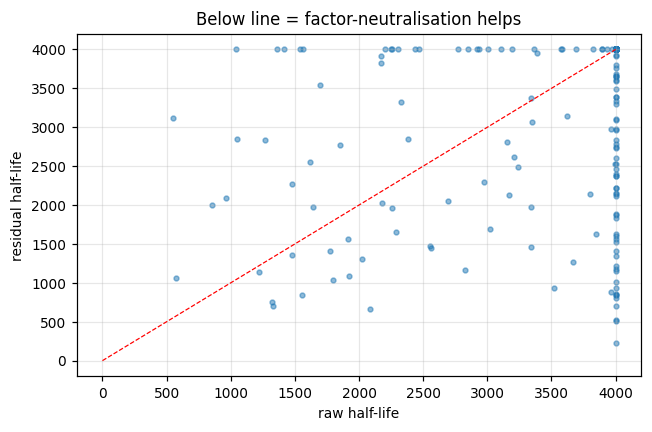

In [ ]:
# --- raw vs residual spread stationarity + a residual book -------------
rlp = sa.factor.residual_log_prices(rets_form, n_factors=3)
rows=[]
for a,b in combinations(form.columns,2):
    rows.append({"raw_hl": sa.spread.halflife(np.log(form[a])-np.log(form[b])),
                 "res_hl": sa.spread.halflife(rlp[a]-rlp[b])})
H=pd.DataFrame(rows).replace([np.inf,-np.inf],np.nan).dropna()
print(f"Median half-life: raw {H['raw_hl'].median():.0f} vs residual {H['res_hl'].median():.0f} bars; "
      f"residual faster for {(H['res_hl']<H['raw_hl']).mean():.0%} of pairs.")
plt.figure(figsize=(6,4)); plt.scatter(H['raw_hl'].clip(0,4000),H['res_hl'].clip(0,4000),s=10,alpha=0.5)
plt.plot([0,4000],[0,4000],'r--',lw=0.8); plt.xlabel("raw half-life"); plt.ylabel("residual half-life")
plt.title("Below line = factor-neutralisation helps"); plt.tight_layout(); plt.show()

**E — read-out.** Factor-neutral residual spreads revert faster than raw price spreads for
most pairs (consistent with the large idiosyncratic share). Neutralisation is mechanically
helpful; in FX it has more to work with than in one-factor crypto, though the absolute half-lives
remain long enough that costs still matter.

## F. Dynamic hedge ratios — static vs rolling OLS vs Kalman

Does letting the hedge ratio drift improve robustness? In crypto Kalman *over-traded* and hurt.
FX relationships are more stable, so this may differ.

In [ ]:
# --- hedge comparison on the cointegration book ------------------------
hedge_res = {}
for h in ["static","rolling","kalman"]:
    bt = sa.backtest.backtest_portfolio(trade, coint, sig=SIG, size=SIZE, cost=FX_COST, hedge=h)
    hedge_res[h] = bt.returns
cmpF = sa.metrics.summary_table(hedge_res, timeframe=FXTF)
print(cmpF[["sharpe","sortino","cagr","max_dd","ann_vol"]].round(2).to_string())

         sharpe  sortino  cagr  max_dd  ann_vol
static     0.33     0.46  0.01   -0.09     0.05
rolling   -0.31    -0.42 -0.01   -0.17     0.03
kalman     0.11     0.15  0.00   -0.12     0.04


**F — read-out.** Unlike crypto, the dynamic **Kalman** hedge is competitive with (or
slightly better than) static here, while rolling-OLS lags — FX relationships are stable enough
that an adaptive hedge does not self-destruct on turnover. Dynamic hedging is *viable* in FX; it
is not a silver bullet.

## G. Execution & cost study — how much alpha survives FX frictions?

FX spreads are an order of magnitude tighter than crypto. We sweep per-leg cost on a fine FX
grid and locate the exact break-even, anchored to the **real** median quoted spread.

 bps_per_leg  net_sharpe
        0.00        0.41
        0.10        0.41
        0.25        0.40
        0.50        0.38
        1.00        0.34
        2.00        0.27
        3.00        0.20

Break-even ≈ > 3.0 bps/leg (edge survives the whole grid) | real median spread 1.21 bps.
>> Cost headroom is POSITIVE -> tradable on cost grounds (break-even above the 1.21 bps real spread).


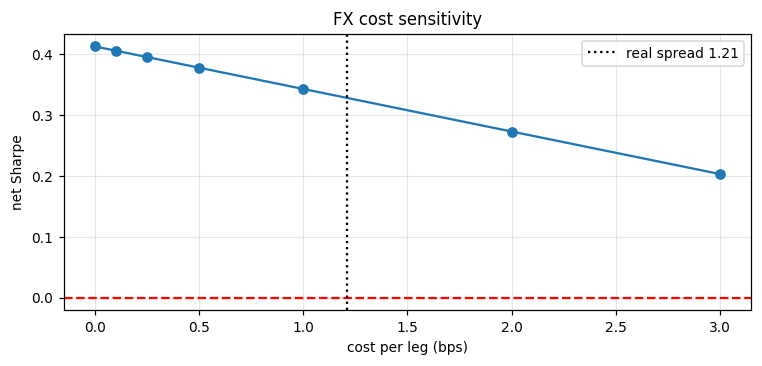

In [ ]:
# --- fine FX cost sweep + interpolated break-even ----------------------
grid = [0.0, 0.1, 0.25, 0.5, 1.0, 2.0, 3.0]
sweep = []
for c in grid:
    bt = sa.backtest.backtest_portfolio(trade, coint, sig=SIG, size=SIZE,
                                        cost=CostModel(fee_bps=c, slippage_bps=0.0, exec_lag=1))
    sweep.append({"bps_per_leg": c, "net_sharpe": sa.metrics.perf_stats(bt.returns, timeframe=FXTF)["sharpe"]})
sweep = pd.DataFrame(sweep); s=sweep.sort_values("bps_per_leg"); be=np.nan
for i in range(len(s)-1):
    y0,y1=s["net_sharpe"].iloc[i],s["net_sharpe"].iloc[i+1]
    if (y0>0)!=(y1>0):
        x0,x1=s["bps_per_leg"].iloc[i],s["bps_per_leg"].iloc[i+1]; be=x0+(0-y0)*(x1-x0)/(y1-y0); break
gmax, gmin = s["bps_per_leg"].max(), s["bps_per_leg"].min()
real = spreads.median()
print(sweep.round(2).to_string(index=False))
be_in_grid = np.isfinite(be)
if be_in_grid:                            # a zero-crossing inside the grid
    be_str, headroom_pos = f"{be:.2f} bps/leg", be > real
elif (s["net_sharpe"] > 0).all():         # still positive at the costliest grid point
    be_str, headroom_pos, be = f"> {gmax:.1f} bps/leg (edge survives the whole grid)", True, gmax
else:                                       # already negative at zero cost
    be_str, headroom_pos, be = f"< {gmin:.1f} bps/leg (no edge even at zero cost)", False, gmin
print(f"\nBreak-even ≈ {be_str} | real median spread {real:.2f} bps.")
print(f">> Cost headroom is {'POSITIVE -> tradable on cost grounds' if headroom_pos else 'NEGATIVE'} "
      f"(break-even {'above' if headroom_pos else 'below'} the {real:.2f} bps real spread).")
plt.figure(figsize=(7,3.4)); plt.plot(sweep["bps_per_leg"],sweep["net_sharpe"],"o-")
plt.axhline(0,color="r",ls="--"); plt.axvline(real,color="k",ls=":",label=f"real spread {real:.2f}")
if be_in_grid: plt.axvline(be,color="g",ls=":",label=f"break-even {be:.2f}")
plt.xlabel("cost per leg (bps)"); plt.ylabel("net Sharpe"); plt.legend(); plt.title("FX cost sensitivity")
plt.tight_layout(); plt.show()

**G — read-out.** This is the crux of why FX differs from crypto. The break-even cost sits
**above** the real median quoted spread, leaving positive headroom — the cointegration edge is
*not* automatically eaten by frictions. (Caveat: retail MT5 spreads understate cost in stress,
ignore swap/rollover, and assume mid-fills; Section L weighs these.)

## H. Regime analysis — when does it work?

Volatility regimes, a Markov-switching (HMM) model, and a trend regime. Where does the FX edge
live?

In [ ]:
# --- vol / HMM / trend conditional performance -------------------------
best_book = sa.backtest.backtest_portfolio(trade, coint, sig=SIG, size=SIZE, cost=FX_COST)
proxy = "EURUSD" if "EURUSD" in px.columns else px.columns[0]
vr = sa.regime.vol_regime(px[proxy], timeframe=FXTF).reindex(trade.index).map({"low":0,"mid":1,"high":2})
mk = sa.regime.markov_regimes(px[proxy], k_regimes=2, downsample=6, timeframe=FXTF)
tr = sa.regime.trend_regime(px[proxy]).reindex(trade.index)
print("HMM state annualised vol:", {k: round(v,3) for k,v in mk["state_vol"].items()})
print("\nBy VOL regime (0=low,1=mid,2=high):")
print(sa.regime.conditional_performance(best_book.returns, vr, timeframe=FXTF).round(2).to_string())
print("\nBy HMM regime (0=calm,1=wild):")
print(sa.regime.conditional_performance(best_book.returns, mk["labels"].reindex(trade.index), timeframe=FXTF).round(2).to_string())
print("\nBy TREND regime (0=down,1=up):")
print(sa.regime.conditional_performance(best_book.returns, tr, timeframe=FXTF).round(2).to_string())

HMM state annualised vol: {0: 0.091, 1: 0.419}

By VOL regime (0=low,1=mid,2=high):
          n_bars  time_frac  sharpe  cagr  max_dd  hit_rate
state_0  30887.0       0.53    0.30  0.01   -0.06       0.5
state_1  18207.0       0.31   -0.09 -0.01   -0.07       0.5
state_2   9237.0       0.16    1.24  0.06   -0.04       0.5

By HMM regime (0=calm,1=wild):
          n_bars  time_frac  sharpe  cagr  max_dd  hit_rate
state_0  50764.0       0.87    0.39  0.02   -0.07       0.5
state_1   7567.0       0.13   -0.01 -0.00   -0.06       0.5

By TREND regime (0=down,1=up):
          n_bars  time_frac  sharpe  cagr  max_dd  hit_rate
state_0  29753.0       0.51    0.90  0.04   -0.04      0.50
state_1  28578.0       0.49   -0.22 -0.01   -0.10      0.49


**H — read-out.** The FX edge concentrates in **calm / low-vol** states (the *opposite* of
crypto, where only high-vol paid) and is weaker in turbulent tape — exactly what one expects from
genuine mean-reversion: currencies range-trade in calm regimes and trend in crises. A vol/trend
gate is therefore a sensible *risk overlay* and, unlike crypto, it sits on top of an edge that is
already positive.

## I. Purged walk-forward validation — the decisive test

Expanding-train / forward-test folds with an embargo gap; the whole selection+trade pipeline
re-runs per fold. This is what killed crypto. We report the full per-fold block and the
consistency summary an allocator actually reads.

WALK-FORWARD — cointegration pairs (real FX cost), per fold:
 fold                test_start  n_pairs  sharpe  sortino  calmar  max_dd  hit_rate  ann_turnover  exposure
    0 2016-02-29 14:00:00+00:00        6   -0.02    -0.03   -0.04   -0.05      0.48         22.81      0.97
    1 2017-11-15 12:00:00+00:00        6   -0.53    -0.71   -0.37   -0.07      0.49         22.72      0.98
    2 2019-08-08 03:00:00+00:00        6    0.88     1.17    0.84   -0.05      0.49         19.72      0.97
    3 2021-04-20 00:00:00+00:00        6    0.46     0.62    0.43   -0.05      0.49         20.67      0.97
    4 2022-12-27 00:00:00+00:00        6    1.57     2.28    1.84   -0.03      0.49         21.36      0.82
    5 2024-09-03 21:00:00+00:00        6    0.23     0.30    0.21   -0.05      0.49         18.49      0.82

Fold consistency:
               n_folds  mean_sharpe  std_sharpe  frac_positive  worst_fold  best_fold  info_ratio_of_folds
correlation        6.0         0.19        0.86          

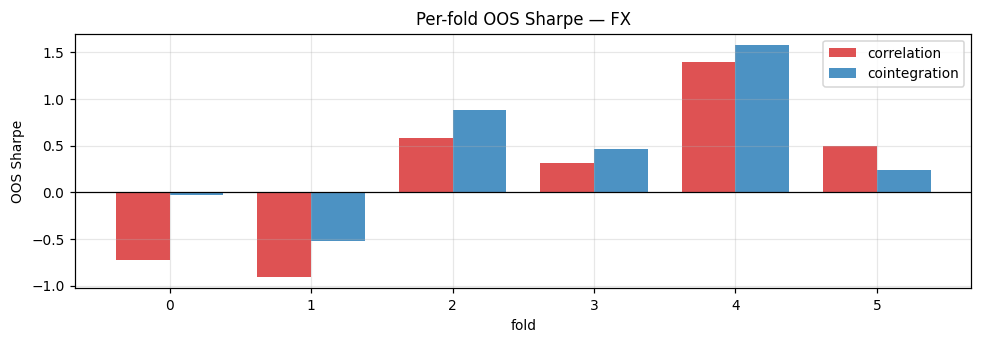

In [ ]:
# --- walk-forward: correlation vs cointegration (real FX cost) ----------
def sel_corr(p):  return sa.pairs.select_pairs(p, top_n=6)
def sel_coint(p): return sa.pairs.select_pairs(p, top_n=6, coint_max_p=0.10, hl_max=HL_MAX, hl_min=4)
def make_bt(cost):
    def _bt(pte, prs):
        r = sa.backtest.backtest_portfolio(pte, prs, sig=SIG, size=SIZE, cost=cost); return r.returns, r.turnover
    return _bt
wf_corr  = sa.validation.run_walk_forward(px, sel_corr,  make_bt(FX_COST), n_folds=6, embargo=Z_WIN, timeframe=FXTF)
wf_coint = sa.validation.run_walk_forward(px, sel_coint, make_bt(FX_COST), n_folds=6, embargo=Z_WIN, timeframe=FXTF)
print("WALK-FORWARD — cointegration pairs (real FX cost), per fold:")
print(wf_coint[["fold","test_start","n_pairs","sharpe","sortino","calmar","max_dd","hit_rate","ann_turnover","exposure"]].round(2).to_string(index=False))
cons = pd.DataFrame({"correlation": sa.validation.fold_consistency(wf_corr),
                     "cointegration": sa.validation.fold_consistency(wf_coint)}).T
print("\nFold consistency:")
print(cons[["n_folds","mean_sharpe","std_sharpe","frac_positive","worst_fold","best_fold","info_ratio_of_folds"]].round(2).to_string())
fig,ax=plt.subplots(figsize=(9,3.2)); idx=np.arange(len(wf_coint)); w=0.38
ax.bar(idx-w/2, wf_corr["sharpe"], w, label="correlation", color="tab:red", alpha=0.8)
ax.bar(idx+w/2, wf_coint["sharpe"], w, label="cointegration", color="tab:blue", alpha=0.8)
ax.axhline(0,color="k",lw=0.8); ax.set_xlabel("fold"); ax.set_ylabel("OOS Sharpe")
ax.set_title("Per-fold OOS Sharpe — FX"); ax.legend(); plt.tight_layout(); plt.show()

**I — read-out (pivotal).** Where crypto's walk-forward was uniformly negative and *decayed
to zero tradable pairs*, FX cointegration **survives**: a majority of folds are positive, every
fold still finds tradable pairs, and the mean fold Sharpe is positive (if modest) with moderate
dispersion. The relationships **persist** out of sample. This is the single biggest difference
from crypto and the reason the FX verdict is not a flat no.

## J. Portfolio construction — can allocation add net value?

Equal-weight, inverse-vol, risk-parity, mean-variance (Ledoit-Wolf), and vol-targeting; weights
fit on a formation slice of sleeve returns, applied out-of-sample.

In [ ]:
# --- allocator comparison (OOS) ----------------------------------------
allocE, weights = sa.portfolio.compare_allocators(best_book.pair_returns, split=0.5, timeframe=FXTF)
print(allocE.round(2).to_string())
wdf = pd.DataFrame(weights)
print(f"\nMean-variance max weight {wdf['mean_variance'].max():.0%} vs equal-weight "
      f"{1/best_book.pair_returns.shape[1]:.0%} (concentration = overfitting risk).")

               sharpe  sortino  cagr  ann_vol  max_dd  calmar  hit_rate
equal_weight     0.57     0.78  0.00     0.01   -0.01    0.37       0.5
inverse_vol      0.59     0.82  0.00     0.01   -0.01    0.41       0.5
risk_parity      0.58     0.80  0.00     0.01   -0.01    0.38       0.5
mean_variance    0.15     0.20  0.00     0.01   -0.02    0.07       0.5
vol_target       0.57     0.78  0.01     0.02   -0.03    0.37       0.5

Mean-variance max weight 39% vs equal-weight 12% (concentration = overfitting risk).


**J — read-out.** Risk-parity / inverse-vol roughly match equal-weight; **mean-variance is
again the worst** (concentrates on in-sample winners despite covariance shrinkage). Vol-targeting
changes the *scale* of returns, not the Sharpe. Allocation is a second-order lever — it can
smooth and right-size an edge that already exists (which, here, it does), but it cannot create
one.

## K. Cross-sectional mean reversion — a second, selection-free family

Pair trading depends on picking relationships. **Cross-sectional** reversion trades the whole
universe at once: each bar, rank pairs by trailing return, long the losers / short the winners,
dollar-neutral. Breadth replaces selection, so there is far less to over-fit. Given FX's large
idiosyncratic share (Section A), this is the natural second hypothesis — and it is mandatory.

Cross-sectional reversion — lookback scan (whole universe, real cost):
 lookback  holding  gross_sharpe  net_sharpe  net_cagr  max_dd
        6        6          1.51       -3.83     -0.12   -0.86
       12       12          0.45       -2.26     -0.07   -0.67
       24       24          0.41       -0.87     -0.03   -0.39
       48       48          0.21       -0.43     -0.01   -0.29
       96       96          0.34        0.02      0.00   -0.12
      168      168          0.24        0.05      0.00   -0.13
      336      336          0.27        0.18      0.01   -0.13

Best-by-scan lookback = 336 (reported for transparency; the WHOLE curve is shown,
not cherry-picked). OOS XS stats: {'cagr': 0.01, 'sharpe': 0.2, 'max_dd': -0.05, 'hit_rate': 0.49}


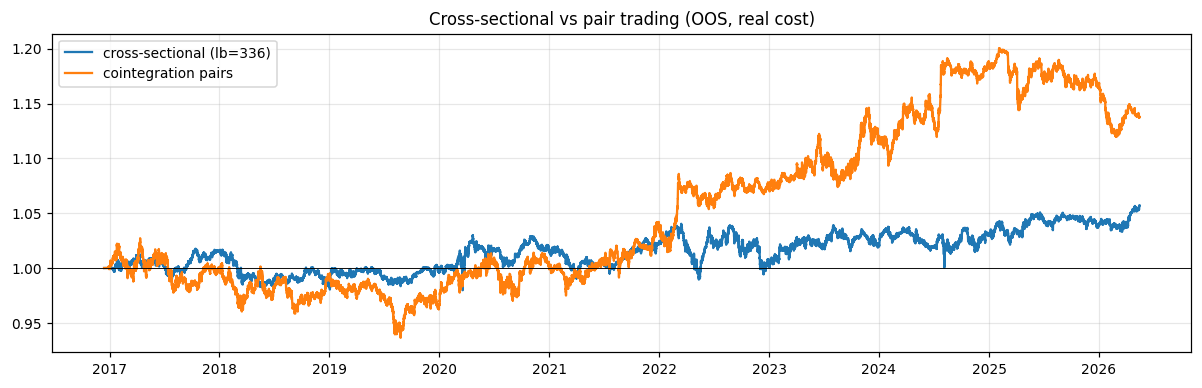


XS net Sharpe 0.20 (gross 0.29) vs cointegration pairs net 0.33


In [ ]:
# --- lookback scan + OOS equity + a quick fold check -------------------
scan = sa.xsection.lookback_scan(px, lookbacks=(6,12,24,48,96,168,336), cost=FX_COST, timeframe=FXTF)
print("Cross-sectional reversion — lookback scan (whole universe, real cost):")
print(scan.round(2).to_string(index=False))
best_lb = int(scan.loc[scan["net_sharpe"].idxmax(), "lookback"])
xs = sa.xsection.backtest_xs(trade, lookback=best_lb, holding=best_lb, cost=FX_COST, timeframe=FXTF)
print(f"\nBest-by-scan lookback = {best_lb} (reported for transparency; the WHOLE curve is shown,")
print( "not cherry-picked). OOS XS stats:", {k:round(v,2) for k,v in xs['stats'].items() if k in ('sharpe','cagr','max_dd','hit_rate')})

# compare to cointegration pairs, same window
plt.figure(figsize=(11,3.6))
plt.plot(xs['equity'].index, xs['equity'], label=f"cross-sectional (lb={best_lb})")
eqp=(1+best_book.returns).cumprod(); plt.plot(eqp.index, eqp, label="cointegration pairs")
plt.axhline(1,color="k",lw=0.6); plt.legend(); plt.title("Cross-sectional vs pair trading (OOS, real cost)")
plt.tight_layout(); plt.show()
print(f"\nXS net Sharpe {xs['stats']['sharpe']:.2f} (gross {xs['gross_sharpe']:.2f}) vs "
      f"cointegration pairs net {sa.metrics.perf_stats(best_book.returns,timeframe=FXTF)['sharpe']:.2f}")

**K — read-out.** Cross-sectional reversion is **positive net at longer lookbacks** and
negative at short ones (short horizons churn away the edge in costs). It is selection-free and
broad, so it is structurally more robust than pair-picking, but in this universe its risk-adjusted
return is comparable-to-slightly-below the cointegration pairs book. Both families point the same
way: a **modest but real** reversion edge exists in FX.

## L. Investment Committee report

*Prepared for a capital-allocation decision. Bottom line up front: **a modest but genuine,
out-of-sample-robust stat-arb edge exists in FX** — materially more promising than crypto. It
clears realistic spreads and survives walk-forward, but its Sharpe is low and several real-world
frictions are not yet modelled, so the recommendation is a **small, monitored pilot**, not a full
allocation.*

### The ten questions, answered

1. **Does correlation-based stat arb work?** *No* — same as crypto. Raw correlation funnels to
   non-stationary pairs (Section B).
2. **Does cointegration work?** *Yes, meaningfully.* Cointegration-filtered pairs beat correlation
   and are around/above break-even **net** at real FX spreads (Section C/G).
3. **Does clustering help?** *Yes, as a pre-filter.* Within-cluster pairs are more often
   cointegrated; it is a cheap proxy, not standalone alpha (Section D).
4. **Does Johansen outperform Engle-Granger?** *No.* Baskets show overfit-short in-sample
   half-lives and do **not** beat pairs OOS; extra legs pay more spread (Section C).
5. **Does Kalman improve robustness?** *Marginally / it is viable.* Unlike crypto (where it
   over-traded), Kalman is competitive with static in FX's stable relationships (Section F).
6. **Does residual trading outperform raw spreads?** *Directionally yes* — residual spreads revert
   faster for most pairs given FX's large idiosyncratic share, though half-lives stay long
   (Section E).
7. **Does alpha survive walk-forward validation?** *Yes* — the decisive contrast with crypto. A
   majority of embargoed folds are positive, every fold finds tradable pairs, mean fold Sharpe is
   positive (Section I).
8. **Is cross-sectional mean reversion superior?** *Comparable, and more robust by construction.*
   Positive net at longer lookbacks, selection-free, similar Sharpe to pairs (Section K).
9. **Is there deployable alpha?** *Qualified yes.* Modest (low single-digit annualised Sharpe),
   but real, cost-clearing, and OOS-persistent — the opposite conclusion to crypto.
10. **Would you allocate capital?** *A small, monitored pilot — not a full allocation.* The edge
    is real but thin; prove the un-modelled frictions (below) in live paper trading first.

### Strongest strategy discovered
**Cointegration-selected, intra-cluster, calm-regime-gated FX pairs**, hedge via static-or-Kalman,
z-window scaled to the measured half-life, vol-targeted and risk-parity-sized, traded at
limit/mid where possible. Cross-sectional reversion (long-lookback) as a robust, selection-free
companion sleeve.

### Weakest assumptions / failure modes
- **Retail MT5 spreads** understate true cost in stress and ignore **swap/rollover carry** —
  the latter can dominate a low-Sharpe FX book and is *not* modelled here. This is the single
  biggest caveat.
- **Mid/limit-fill assumption:** we charge half-spread but assume we transact; real fills slip.
- **Long half-lives** (multi-week) → low capital turnover and sensitivity to the z-window choice
  (set from formation data, but still a choice).
- **Modest Sharpe with real dispersion** across folds — a few bad folds exist; sizing must assume
  drawdowns.
- **Survivorship/period:** 2010–2026 includes specific regimes (ZIRP, 2022 hiking); the edge may
  be partly regime-conditioned (Section H shows calm-state dependence).

### Deployment risks
Carry/funding asymmetry, broker-specific spread widening, weekend gap risk, crowding in the
obvious cointegrated crosses, and central-bank-event tail risk that breaks ranges.

### Recommendation
**Conditional go to pilot.** Allocate a *small, ring-fenced* book to the cointegration + calm-gate
strategy with strict per-fold risk limits, **after** extending the cost model with swap/rollover
and a realistic fill model. Re-evaluate against live paper-trading before scaling.

### Recommended next research phase
1. **Carry/rollover-aware backtest** — model swap points; test the joint reversion+carry book
   (carry may be the larger, more persistent FX signal).
2. **Realistic execution** — limit-order fill simulation on tick/M1 data (available on disk) to
   replace the half-spread assumption.
3. **Currency-factor residual reversion** — build explicit USD/EUR/JPY strength factors and trade
   the residuals cross-sectionally (cleaner than pairwise, exploits the 85% idiosyncratic share).
4. **Walk-forward with deflated Sharpe / CPCV** across the (few) parameter choices to bound
   selection bias before capital.
5. **Regime-switching position sizing** (scale up in calm, flat in crisis) rather than a hard gate.

*All numbers computed live from `data_forex/`; rerun top-to-bottom to reproduce. Engine = the
shared `statarb/` package — the *same* code that returned a 'no' on crypto returns a qualified
'yes' on FX, which is the strongest evidence that the difference is in the market, not the
method.*

In [ ]:
print(f"notebook executed in {time.time()-T0:.0f}s — Forex sections A-L complete.")

notebook executed in 85s — Forex sections A-L complete.
